In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

os.makedirs('figures', exist_ok=True)

df = pd.read_csv('train.csv')
print(df.shape)
print(df.head())
print(df.info())

(31112, 16)
  geological_era weather_pattern region  aptitude_score  performance_score  \
0       Triassic        Heatwave  Texas          325.58              34.95   
1       Triassic         Monsoon  Texas          333.63             256.50   
2       Triassic         Monsoon  Texas          503.96             385.00   
3       Triassic        Heatwave  Texas          404.61             156.44   
4       Triassic        Heatwave  Texas          358.89             144.05   

   stability_index personal_interest  load_ratio brew_preference instrument  \
0            1.503          Foraging      23.878        Espresso   Dulcimer   
1            3.283          Falconry      28.617        Espresso      Cello   
2            3.676         Astronomy      22.582        Espresso      Cello   
3            2.812       Calligraphy      28.002           Latte       Oboe   
4            2.735        Beekeeping      22.062        Espresso       Oboe   

  species  index_weight mineral_type  activi

In [2]:
missing = df.isna().sum().sort_values(ascending=False)
print('Missing values:')
print(missing[missing > 0])

print('Duplicated rows:', df.duplicated().sum())

print('Label distribution:')
print(df['label'].value_counts(dropna=False))
print(df['label'].value_counts(normalize=True, dropna=False))

Missing values:
brew_preference      7
personal_interest    6
region               4
aptitude_score       4
weather_pattern      3
instrument           3
species              3
index_weight         3
mineral_type         3
label                3
geological_era       2
performance_score    2
stability_index      2
load_ratio           2
activity_duration    2
composite_rank       1
dtype: int64
Duplicated rows: 0
Label distribution:
no     23645
yes     7464
NaN        3
Name: label, dtype: int64
no     0.759996
yes    0.239907
NaN    0.000096
Name: label, dtype: float64


In [3]:
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(str).str.strip().str.lower()
df['label'] = df['label'].map({'no': 0, 'yes': 1})
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)

print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))
print(df.shape)

0    23645
1     7464
Name: label, dtype: int64
0    0.760069
1    0.239931
Name: label, dtype: float64
(31109, 16)


In [4]:
num_cols = [
    'aptitude_score',
    'performance_score',
    'stability_index',
    'load_ratio',
    'index_weight',
    'activity_duration',
    'composite_rank'
]

cat_cols = [c for c in df.columns if c not in num_cols + ['label']]

print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print(df[num_cols].describe().T)

print('Categorical column summary:')
for c in cat_cols:
    print(f'{c}: unique={df[c].nunique()}, missing={df[c].isna().sum()}')

Numeric columns: ['aptitude_score', 'performance_score', 'stability_index', 'load_ratio', 'index_weight', 'activity_duration', 'composite_rank']
Categorical columns: ['geological_era', 'weather_pattern', 'region', 'personal_interest', 'brew_preference', 'instrument', 'species', 'mineral_type']
                     count        mean         std     min      25%      50%  \
aptitude_score     31105.0  342.131786   68.926208  90.000  310.590  333.510   
performance_score  31107.0  296.497741  187.627580   0.000  146.570  275.390   
stability_index    31107.0    3.156421    0.849344   0.000    2.751    3.351   
load_ratio         31107.0   24.423331    9.919982   0.000   19.272   23.689   
index_weight       31106.0   12.721624    7.747215   0.000    7.520   11.730   
activity_duration  31107.0   80.362477   25.514176   0.000   72.740   80.330   
composite_rank     31108.0    3.238775    0.869808   0.589    2.591    3.199   

                       75%       max  
aptitude_score     402.56

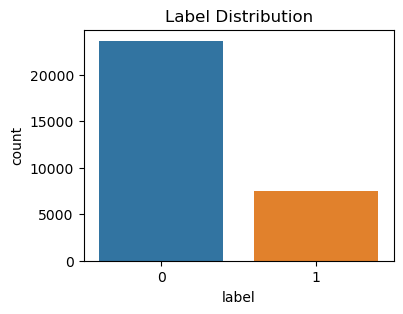

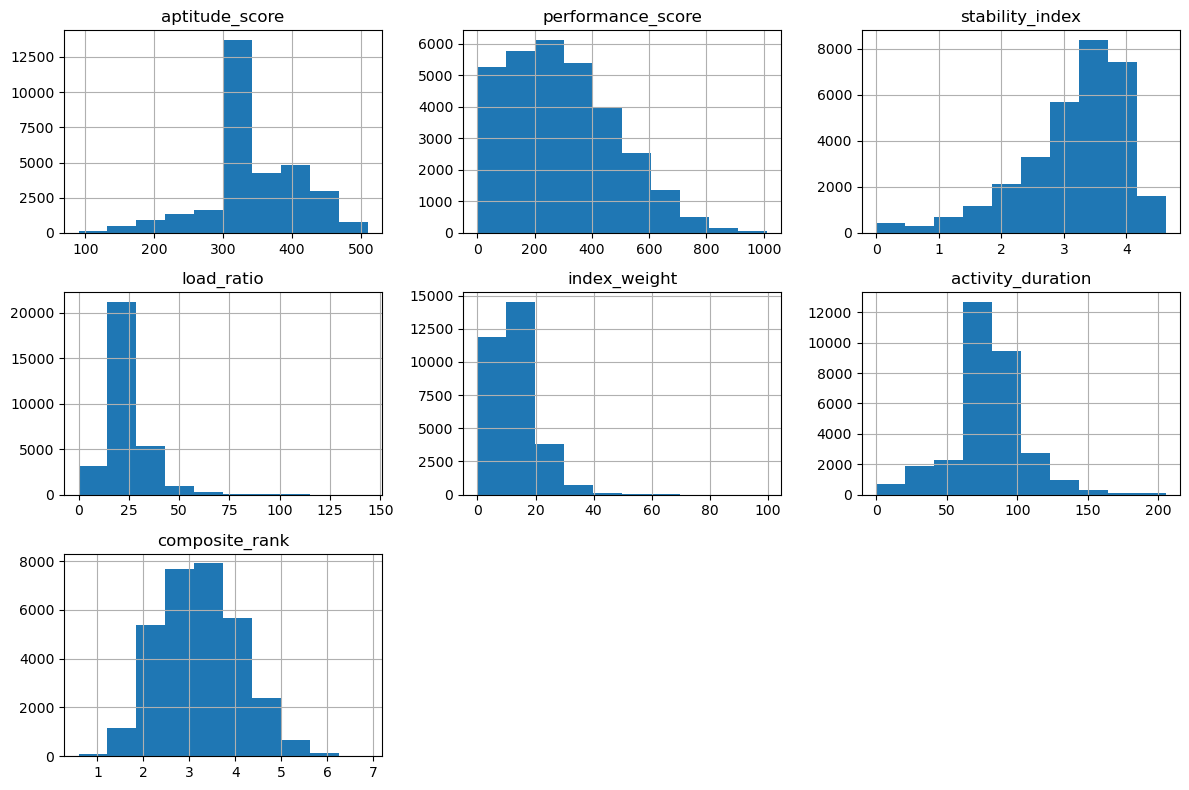

In [5]:
plt.figure(figsize=(4, 3))
sns.countplot(data=df, x='label')
plt.title('Label Distribution')
plt.savefig('figures/label_dist.png', dpi=300, bbox_inches='tight')
plt.show()

df[num_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.savefig('figures/numeric_hist.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
X = df.drop(columns=['label'])
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Train label distribution:')
print(y_train.value_counts(normalize=True))
print('Test label distribution:')
print(y_test.value_counts(normalize=True))

X_train shape: (24887, 15)
X_test shape: (6222, 15)
Train label distribution:
0    0.760076
1    0.239924
Name: label, dtype: float64
Test label distribution:
0    0.760045
1    0.239955
Name: label, dtype: float64


In [7]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

print('Preprocessing pipeline has been built successfully.')

Preprocessing pipeline has been built successfully.


In [8]:
log_reg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

print('Logistic Regression pipeline and Random Forest pipeline are ready.')

Logistic Regression pipeline and Random Forest pipeline are ready.


In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['liblinear'],
    'classifier__penalty': ['l2']
}

rf_param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_leaf': [1, 5],
    'classifier__max_features': ['sqrt']
}

print('Cross-validation strategy and parameter grids are ready.')

Cross-validation strategy and parameter grids are ready.


In [10]:
lr_grid = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=lr_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)

print('Best Logistic Regression params:')
print(lr_grid.best_params_)
print('Best Logistic Regression CV F1:')
print(lr_grid.best_score_)

print('\nBest Random Forest params:')
print(rf_grid.best_params_)
print('Best Random Forest CV F1:')
print(rf_grid.best_score_)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Logistic Regression params:
{'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'liblinear'}
Best Logistic Regression CV F1:
0.6614832010779591

Best Random Forest params:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best Random Forest CV F1:
0.6670960708249337



===== Logistic Regression =====
Accuracy : 0.787367405978785
Precision: 0.5357142857142857
Recall   : 0.853985264567984
F1       : 0.6584043377226956
ROC-AUC  : 0.8855645086246566
PR-AUC   : 0.6942870759098054

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      4729
           1       0.54      0.85      0.66      1493

    accuracy                           0.79      6222
   macro avg       0.74      0.81      0.75      6222
weighted avg       0.85      0.79      0.80      6222



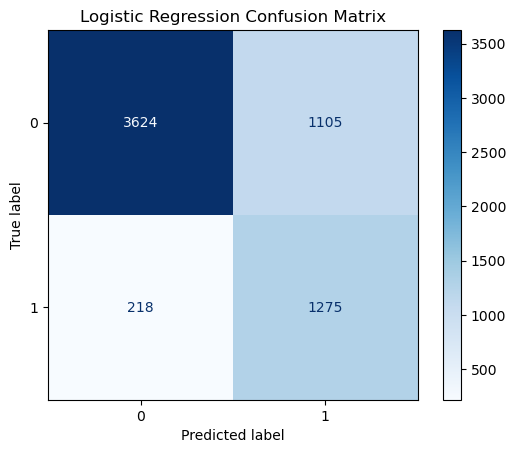


===== Random Forest =====
Accuracy : 0.8100289296046287
Precision: 0.5760391198044009
Recall   : 0.7890154052243804
F1       : 0.6659129451667608
ROC-AUC  : 0.8848707799292306
PR-AUC   : 0.6957316112564939

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      4729
           1       0.58      0.79      0.67      1493

    accuracy                           0.81      6222
   macro avg       0.75      0.80      0.77      6222
weighted avg       0.84      0.81      0.82      6222



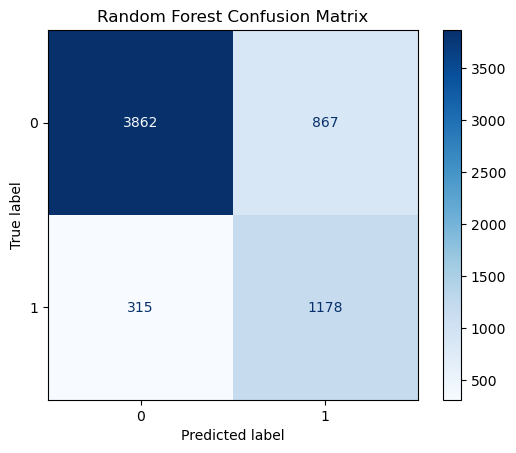

In [11]:
from sklearn.metrics import average_precision_score, precision_recall_curve, ConfusionMatrixDisplay
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f'\n===== {name} =====')
    print('Accuracy :', accuracy_score(y_test, y_pred))
    print('Precision:', precision_score(y_test, y_pred, zero_division=0))
    print('Recall   :', recall_score(y_test, y_pred, zero_division=0))
    print('F1       :', f1_score(y_test, y_pred, zero_division=0))
    print('ROC-AUC  :', roc_auc_score(y_test, y_prob))
    print('PR-AUC   :', average_precision_score(y_test, y_prob))

    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.savefig(f'figures/{name}_confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model(
    'Logistic Regression',
    lr_grid.best_estimator_,
    X_test,
    y_test
)

rf_pred, rf_prob = evaluate_model(
    'Random Forest',
    rf_grid.best_estimator_,
    X_test,
    y_test
)

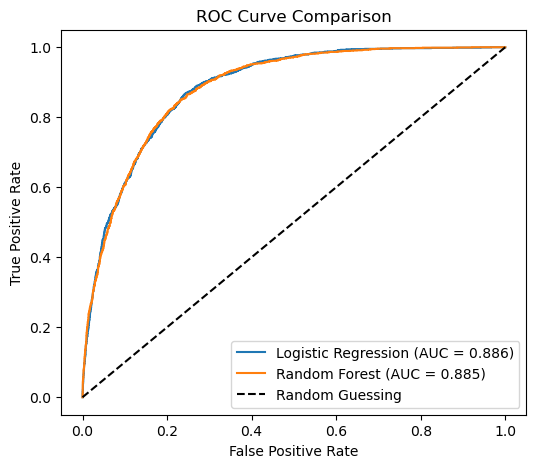

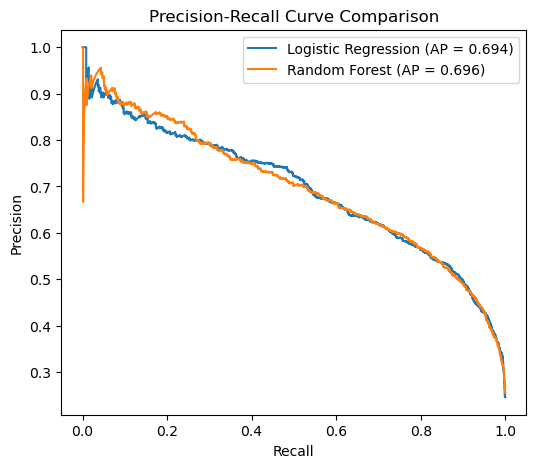

In [12]:
plt.figure(figsize=(6, 5))
for name, prob in [
    ('Logistic Regression', lr_prob),
    ('Random Forest', rf_prob)
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc_score(y_test, prob):.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.savefig('figures/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(6, 5))
for name, prob in [
    ('Logistic Regression', lr_prob),
    ('Random Forest', rf_prob)
]:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    plt.plot(
        recall,
        precision,
        label=f'{name} (AP = {average_precision_score(y_test, prob):.3f})'
    )

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.savefig('figures/pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
best_rf = rf_grid.best_estimator_
pre_rf = best_rf.named_steps['preprocessor']
clf_rf = best_rf.named_steps['classifier']

num_features = num_cols
cat_encoder_rf = pre_rf.named_transformers_['cat'].named_steps['onehot']
cat_features_rf = cat_encoder_rf.get_feature_names_out(cat_cols).tolist()
feature_names_rf = num_features + cat_features_rf

rf_importances = pd.Series(
    clf_rf.feature_importances_,
    index=feature_names_rf
).sort_values(ascending=False)

print('Top 20 Random Forest feature importances:')
print(rf_importances.head(20))

rf_importances.head(20).to_csv(
    'figures/rf_feature_importance_top20.csv',
    header=['importance']
)

best_lr = lr_grid.best_estimator_
pre_lr = best_lr.named_steps['preprocessor']
clf_lr = best_lr.named_steps['classifier']

cat_encoder_lr = pre_lr.named_transformers_['cat'].named_steps['onehot']
cat_features_lr = cat_encoder_lr.get_feature_names_out(cat_cols).tolist()
feature_names_lr = num_cols + cat_features_lr

lr_coefs = pd.Series(
    clf_lr.coef_[0],
    index=feature_names_lr
).sort_values(key=abs, ascending=False)

print('\nTop 20 Logistic Regression coefficients by absolute value:')
print(lr_coefs.head(20))

lr_coefs.head(20).to_csv(
    'figures/lr_top_coefficients.csv',
    header=['coefficient']
)

Top 20 Random Forest feature importances:
weather_pattern_Monsoon          0.137449
composite_rank                   0.106012
aptitude_score                   0.102136
instrument_Cello                 0.086943
performance_score                0.067187
stability_index                  0.064183
activity_duration                0.061284
weather_pattern_Heatwave         0.055260
load_ratio                       0.043277
index_weight                     0.028046
instrument_Oboe                  0.023904
instrument_Zither                0.019657
brew_preference_Latte            0.016677
personal_interest_Falconry       0.016666
brew_preference_Espresso         0.016326
instrument_Dulcimer              0.014885
personal_interest_Astronomy      0.012564
personal_interest_Kite-flying    0.010461
mineral_type_Sapphire            0.010423
mineral_type_Marble              0.010037
dtype: float64

Top 20 Logistic Regression coefficients by absolute value:
stability_index                  2.035056
w

In [14]:
metrics = []

for name, pred, prob in [
    ('Logistic Regression', lr_pred, lr_prob),
    ('Random Forest', rf_pred, rf_prob)
]:
    metrics.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 4),
        'Recall': round(recall_score(y_test, pred, zero_division=0), 4),
        'F1': round(f1_score(y_test, pred, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(y_test, prob), 4),
        'PR-AUC': round(average_precision_score(y_test, prob), 4)
    })

metrics_df = pd.DataFrame(metrics).sort_values('F1', ascending=False)

print(metrics_df)
metrics_df.to_csv('figures/model_metrics.csv', index=False)

                 Model  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
1        Random Forest    0.8100     0.5760   0.789  0.6659   0.8849  0.6957
0  Logistic Regression    0.7874     0.5357   0.854  0.6584   0.8856  0.6943
